In [2]:
import math

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + math.exp(-z))

In [3]:
def loss(data, w0, w1, w2):
    N = len(data)
    total = 0.0
    
    for x1, x2, yi in data:
        y_hat = w1 * x1 + w2 * x2 + w0
        z = yi * y_hat - math.log(1 + math.exp(y_hat))
        
        total += z
        
    return -(1 / N) * total

In [19]:
def gradient_descent(data, lr, thres):
    w0 = 0.0
    w1 = 1.0
    w2 = 2.0
    
    N = len(data)
    i = 0
    J_prev = 0.0 
    
    while True:
        i += 1
        
        J = loss(data, w0, w1, w2)

        if abs(J - J_prev) < thres:
            print(f"Converged at iteration {i}, J = {J}")
            break
        
        J_prev = J 
        
        print(f"{i} | {w0:.4f} | {w1:.4f} | {w2:.4f} | {J:.4f}")
        
        dw0 = 0.0
        dw1 = 0.0
        dw2 = 0.0 
        
        for x1, x2, yi in data:
            z = w1 * x1 + w2 * x2 + w0

            prediction = sigmoid(z)
            error = prediction - yi
            
            dw0 += error
            dw1 += x1 * error
            dw2 += x2 * error
            
        dw0 /= N
        dw1 /= N
        dw2 /= N
 
        w0 = w0 - lr * dw0
        w1 = w1 - lr * dw1
        w2 = w2 - lr * dw2
    
    return w0, w1, w2


In [20]:
data = []
with open("loan2.csv", "r") as f:
    next(f) 
    for line in f:
        if line.strip():
            x, y, z = line.strip().split(",")
            data.append((float(x), float(y), float(z)))
        
print(data)

[(3.0, 4.0, 1.0), (2.5, 4.0, 1.0), (1.0, 4.0, 0.0), (2.5, 5.0, 1.0), (2.0, 5.0, 1.0), (1.5, 5.0, 0.0), (0.5, 5.0, 0.0), (1.75, 6.0, 1.0), (0.25, 6.0, 0.0), (1.0, 7.0, 1.0), (0.25, 7.0, 0.0), (0.2, 7.0, 0.0), (0.15, 7.0, 0.0), (2.0, 8.0, 1.0), (1.0, 8.0, 0.0), (0.15, 8.0, 0.0), (0.1, 8.0, 0.0), (0.5, 9.0, 1.0), (1.0, 10.0, 1.0)]


In [21]:
lr = 0.001
thres = 1e-6

w0, w1, w2 = gradient_descent(data, lr, thres)

1 | 0.0000 | 1.0000 | 2.0000 | 7.1105
2 | -0.0005 | 0.9997 | 1.9966 | 7.0985
3 | -0.0011 | 0.9995 | 1.9932 | 7.0864
4 | -0.0016 | 0.9992 | 1.9897 | 7.0744
5 | -0.0021 | 0.9989 | 1.9863 | 7.0623
6 | -0.0026 | 0.9987 | 1.9829 | 7.0503
7 | -0.0032 | 0.9984 | 1.9795 | 7.0382
8 | -0.0037 | 0.9981 | 1.9761 | 7.0262
9 | -0.0042 | 0.9979 | 1.9726 | 7.0141
10 | -0.0047 | 0.9976 | 1.9692 | 7.0021
11 | -0.0053 | 0.9973 | 1.9658 | 6.9900
12 | -0.0058 | 0.9970 | 1.9624 | 6.9780
13 | -0.0063 | 0.9968 | 1.9589 | 6.9659
14 | -0.0068 | 0.9965 | 1.9555 | 6.9539
15 | -0.0074 | 0.9962 | 1.9521 | 6.9418
16 | -0.0079 | 0.9960 | 1.9487 | 6.9298
17 | -0.0084 | 0.9957 | 1.9453 | 6.9177
18 | -0.0089 | 0.9954 | 1.9418 | 6.9057
19 | -0.0095 | 0.9952 | 1.9384 | 6.8936
20 | -0.0100 | 0.9949 | 1.9350 | 6.8815
21 | -0.0105 | 0.9946 | 1.9316 | 6.8695
22 | -0.0111 | 0.9944 | 1.9282 | 6.8574
23 | -0.0116 | 0.9941 | 1.9247 | 6.8454
24 | -0.0121 | 0.9938 | 1.9213 | 6.8333
25 | -0.0126 | 0.9936 | 1.9179 | 6.8213
26 | -0.01

In [22]:
lr = 0.01
thres = 1e-6

w0, w1, w2 = gradient_descent(data, lr, thres)

1 | 0.0000 | 1.0000 | 2.0000 | 7.1105
2 | -0.0053 | 0.9973 | 1.9658 | 6.9900
3 | -0.0105 | 0.9946 | 1.9316 | 6.8695
4 | -0.0158 | 0.9919 | 1.8974 | 6.7490
5 | -0.0211 | 0.9893 | 1.8632 | 6.6285
6 | -0.0263 | 0.9866 | 1.8290 | 6.5079
7 | -0.0316 | 0.9839 | 1.7947 | 6.3874
8 | -0.0368 | 0.9812 | 1.7605 | 6.2669
9 | -0.0421 | 0.9785 | 1.7263 | 6.1464
10 | -0.0474 | 0.9758 | 1.6921 | 6.0259
11 | -0.0526 | 0.9732 | 1.6579 | 5.9054
12 | -0.0579 | 0.9705 | 1.6237 | 5.7849
13 | -0.0632 | 0.9678 | 1.5895 | 5.6643
14 | -0.0684 | 0.9651 | 1.5553 | 5.5438
15 | -0.0737 | 0.9624 | 1.5211 | 5.4234
16 | -0.0789 | 0.9597 | 1.4869 | 5.3029
17 | -0.0842 | 0.9571 | 1.4527 | 5.1824
18 | -0.0895 | 0.9544 | 1.4185 | 5.0619
19 | -0.0947 | 0.9517 | 1.3843 | 4.9414
20 | -0.1000 | 0.9490 | 1.3501 | 4.8210
21 | -0.1052 | 0.9463 | 1.3159 | 4.7006
22 | -0.1105 | 0.9437 | 1.2817 | 4.5801
23 | -0.1158 | 0.9410 | 1.2475 | 4.4597
24 | -0.1210 | 0.9383 | 1.2133 | 4.3393
25 | -0.1263 | 0.9356 | 1.1791 | 4.2190
26 | -0.13

In [25]:
lr = 0.1
thres = 1e-6

w0, w1, w2 = gradient_descent(data, lr, thres)

1 | 0.0000 | 1.0000 | 2.0000 | 7.1105
2 | -0.0526 | 0.9732 | 1.6579 | 5.9053
3 | -0.1053 | 0.9463 | 1.3158 | 4.7004
4 | -0.1579 | 0.9195 | 0.9739 | 3.4970
5 | -0.2103 | 0.8929 | 0.6326 | 2.3042
6 | -0.2619 | 0.8670 | 0.2966 | 1.1932
7 | -0.3066 | 0.8461 | 0.0045 | 0.5535
8 | -0.3234 | 0.8459 | -0.0921 | 0.5068
9 | -0.3260 | 0.8581 | -0.0890 | 0.5053
10 | -0.3294 | 0.8694 | -0.0902 | 0.5039
11 | -0.3327 | 0.8806 | -0.0912 | 0.5025
12 | -0.3361 | 0.8916 | -0.0922 | 0.5012
13 | -0.3395 | 0.9023 | -0.0932 | 0.4999
14 | -0.3429 | 0.9129 | -0.0942 | 0.4987
15 | -0.3464 | 0.9233 | -0.0951 | 0.4975
16 | -0.3498 | 0.9335 | -0.0959 | 0.4963
17 | -0.3533 | 0.9435 | -0.0968 | 0.4952
18 | -0.3569 | 0.9534 | -0.0976 | 0.4941
19 | -0.3604 | 0.9631 | -0.0984 | 0.4930
20 | -0.3640 | 0.9727 | -0.0992 | 0.4920
21 | -0.3675 | 0.9820 | -0.1000 | 0.4910
22 | -0.3711 | 0.9913 | -0.1007 | 0.4900
23 | -0.3748 | 1.0004 | -0.1014 | 0.4890
24 | -0.3784 | 1.0093 | -0.1020 | 0.4881
25 | -0.3821 | 1.0181 | -0.1027 |

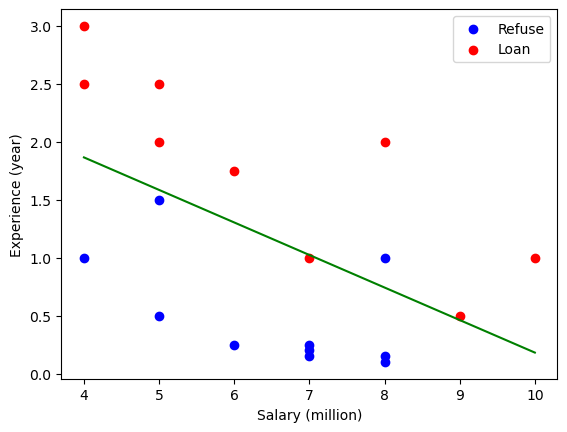

In [24]:
import matplotlib.pyplot as plt

xs_0 = [d[1] for d in data if d[2] == 0]
ys_0 = [d[0] for d in data if d[2] == 0]
xs_1 = [d[1] for d in data if d[2] == 1]
ys_1 = [d[0] for d in data if d[2] == 1]

plt.scatter(xs_0, ys_0, color='blue', label='Refuse')
plt.scatter(xs_1, ys_1, color='red', label='Loan')

x_min = min([d[1] for d in data])
x_max = max([d[1] for d in data])

y_min = -(w2 * x_min + w0) / w1
y_max = -(w2 * x_max + w0) / w1

plt.plot([x_min, x_max], [y_min, y_max], color='green')

plt.xlabel('Salary (million)')
plt.ylabel('Experience (year)')
plt.legend()
plt.show()